# Decision Tree and K-Nearest Neighbour (KNN) for Classification using the diabetes dataset.

# Import Libraries and Load Dataset

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve
)

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
# Styling for plots
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('diabetes.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Data Preprocessing & Missing Value Handling

In [8]:
# Handle biological zeros as missing values and fill them cleanly
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)

# Define feature matrix (X) and target vector (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Use SimpleImputer to fill any NaN values with the training set median
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Feature Scaling (Crucial for distance-based models like KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print(f"Any NaNs in X_train_scaled? {np.isnan(X_train_scaled).any()}")
print(f"Training set shape: {X_train_scaled.shape}")

Any NaNs in X_train_scaled? False
Training set shape: (614, 8)


# Implement & Visualize Decision Tree

--- Decision Tree Performance ---
Accuracy: 0.7857
ROC-AUC: 0.7887

              precision    recall  f1-score   support

           0       0.83      0.84      0.84       100
           1       0.70      0.69      0.69        54

    accuracy                           0.79       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.79      0.79       154



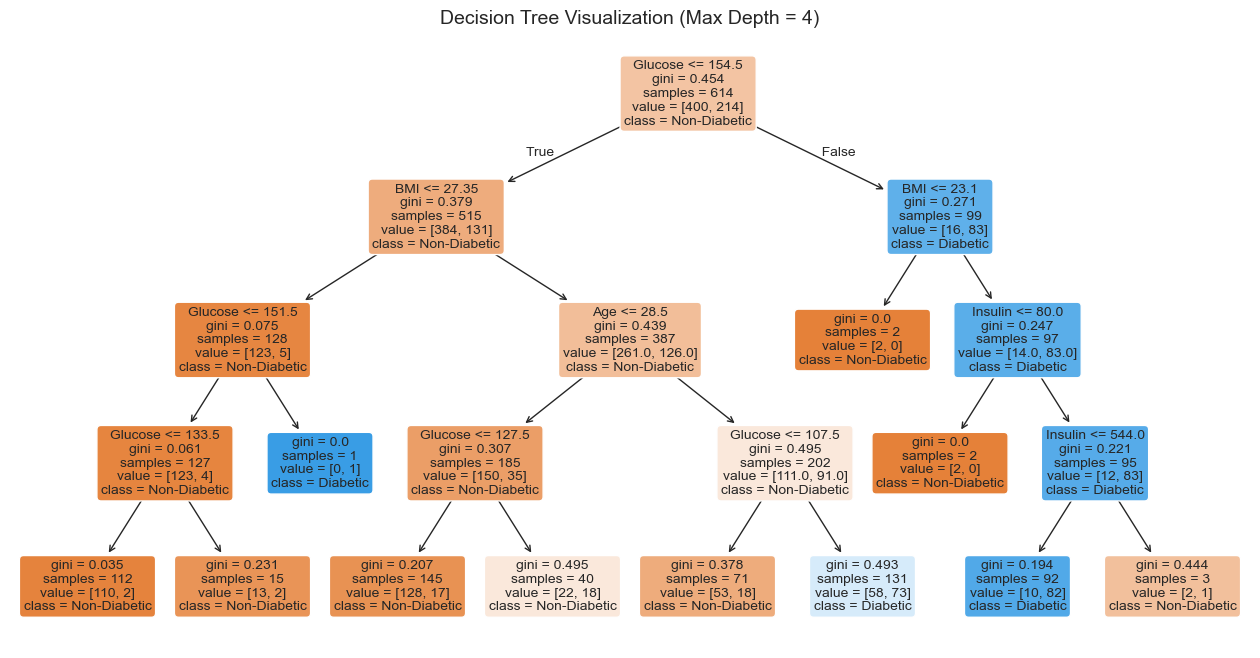

In [9]:
# Initialize and train Decision Tree Classifier using Gini Index
dt_classifier = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt_classifier.fit(X_train, y_train)

# Predictions
dt_pred = dt_classifier.predict(X_test)
dt_prob = dt_classifier.predict_proba(X_test)[:, 1]

# Evaluation
print("--- Decision Tree Performance ---")
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, dt_prob):.4f}\n")
print(classification_report(y_test, dt_pred))

# Plot Decision Tree Structure
plt.figure(figsize=(16, 8))
plot_tree(
    dt_classifier, 
    feature_names=X.columns.tolist(), 
    class_names=['Non-Diabetic', 'Diabetic'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Decision Tree Visualization (Max Depth = 4)", fontsize=14)
plt.show()

# Implement K-Nearest Neighbors (KNN) & Distance Tuning

In [10]:
# Initialize and train KNN Classifier (using Euclidean distance metric)
knn_classifier = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_classifier.fit(X_train_scaled, y_train)

# Predictions
knn_pred = knn_classifier.predict(X_test_scaled)
knn_prob = knn_classifier.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("--- K-Nearest Neighbors (KNN) Performance ---")
print(f"Accuracy: {accuracy_score(y_test, knn_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, knn_prob):.4f}\n")
print(classification_report(y_test, knn_pred))

--- K-Nearest Neighbors (KNN) Performance ---
Accuracy: 0.7532
ROC-AUC: 0.7899

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



# Final Summary

In [11]:
# Summary comparison DataFrame for your notebook report
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "K-Nearest Neighbors"],
    "Accuracy": [accuracy_score(y_test, dt_pred), accuracy_score(y_test, knn_pred)],
    "Precision": [precision_score(y_test, dt_pred), precision_score(y_test, knn_pred)],
    "Recall": [recall_score(y_test, dt_pred), recall_score(y_test, knn_pred)],
    "F1-Score": [f1_score(y_test, dt_pred), f1_score(y_test, knn_pred)],
    "ROC-AUC": [roc_auc_score(y_test, dt_prob), roc_auc_score(y_test, knn_prob)]
})

display(comparison_df.style.background_gradient(cmap='Blues', subset=['Accuracy', 'F1-Score', 'ROC-AUC']))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.785714,0.698113,0.685185,0.691589,0.788704
1,K-Nearest Neighbors,0.753247,0.660000,0.611111,0.634615,0.789907
